# From Data to Insight: Visual Encoding in Practice

**Unit 1 — Foundations of Visualization, Data Interpretation (UE24CS342AA9)**




In [1]:
# --- Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("apple_products_pricing_2020_2026.csv", parse_dates=["Date"])
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()


Rows: 80,000  |  Columns: ['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition', 'Launch_Price_USD', 'Launch_Price_INR', 'Current_Price_USD', 'Current_Price_INR', 'Discount_Pct', 'Sale_Event', 'Stock_Status', 'Rating', 'Reviews_Count']


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35


## 1. Understanding Data Variables and Types  *(Slide 9)*

Before we can pick a visual encoding, we have to know **what kind of variable** we're
encoding. The lecture gave us four buckets:

| Type | Definition | Example in this dataset |
|---|---|---|
| **Continuous quantitative** | Arbitrary real numbers | `Current_Price_USD`, `Discount_Pct` |
| **Discrete quantitative** | Integer counts | `Reviews_Count` |
| **Unordered qualitative** | Categories, no order | `Platform`, `Product_Category`, `Model_Name` |
| **Ordered qualitative** | Categories with a logical sequence | `Stock_Status` (Out of Stock < Low Stock < In Stock) |

🔧 **Try it:** `Rating` is a float, but is it really *continuous*? In practice star ratings
are often treated as **ordered qualitative** (or discrete quantitative) because there are
only a limited number of realistic values. Run the cell below and see for yourself.


In [2]:
print("Unique Rating values:", sorted(df['Rating'].unique())[:15], "...")
print("Number of distinct ratings:", df['Rating'].nunique())
print()
print("Column-by-column classification:")
classification = {
    "Date": "Continuous (temporal)",
    "Platform": "Unordered qualitative",
    "Product_Category": "Unordered qualitative",
    "Model_Name": "Unordered qualitative (high-cardinality)",
    "Condition": "Unordered qualitative (binary)",
    "Launch_Price_USD": "Continuous quantitative",
    "Current_Price_USD": "Continuous quantitative",
    "Discount_Pct": "Continuous quantitative",
    "Sale_Event": "Unordered qualitative",
    "Stock_Status": "Ordered qualitative",
    "Rating": "Discrete quantitative / Ordered qualitative",
    "Reviews_Count": "Discrete quantitative",
}
for col, kind in classification.items():
    print(f"  {col:20s} -> {kind}")


Unique Rating values: [np.float64(3.8), np.float64(3.9), np.float64(4.0), np.float64(4.1), np.float64(4.2), np.float64(4.3), np.float64(4.4), np.float64(4.5), np.float64(4.6), np.float64(4.7), np.float64(4.8), np.float64(4.9)] ...
Number of distinct ratings: 12

Column-by-column classification:
  Date                 -> Continuous (temporal)
  Platform             -> Unordered qualitative
  Product_Category     -> Unordered qualitative
  Model_Name           -> Unordered qualitative (high-cardinality)
  Condition            -> Unordered qualitative (binary)
  Launch_Price_USD     -> Continuous quantitative
  Current_Price_USD    -> Continuous quantitative
  Discount_Pct         -> Continuous quantitative
  Sale_Event           -> Unordered qualitative
  Stock_Status         -> Ordered qualitative
  Rating               -> Discrete quantitative / Ordered qualitative
  Reviews_Count        -> Discrete quantitative


## 2. Visual Primitives: Marks vs. Channels  *(Slide 7)*

- **Marks** are the geometric objects: points, lines, bars.
- **Channels** (aesthetics) are the properties of those marks we vary to encode data:
  position, color, size, shape, line width.

Below, every dot is a **mark** (a point, one per day-platform-model row, sampled for
clarity). We then reuse the *same* marks and change only the **channels** to show how
much more information a single scatter of points can carry.


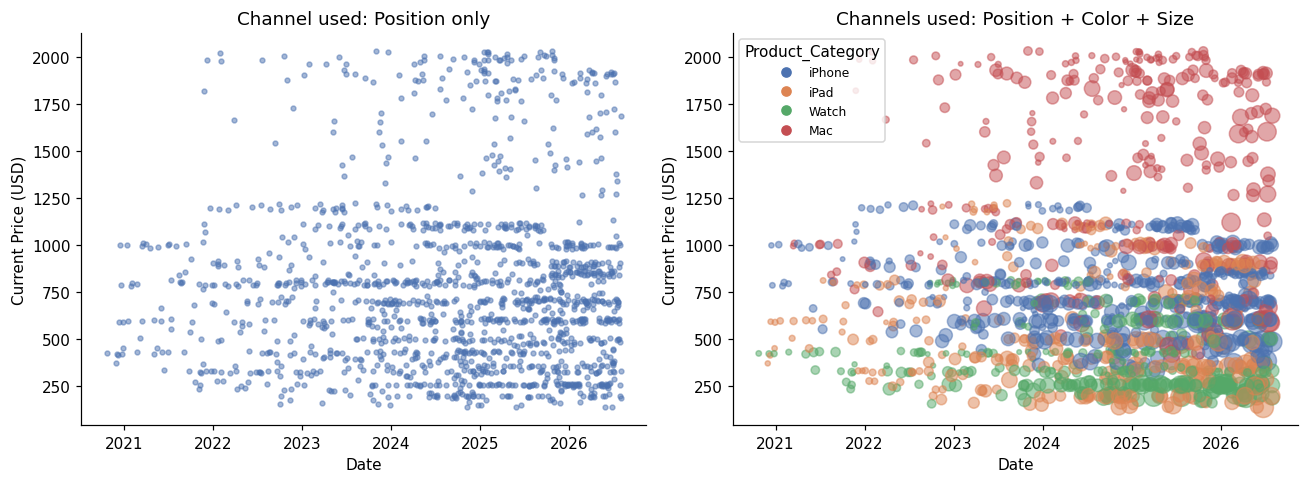

Same marks (points), more channels (color=category, size=reviews) -> more data per mark.


In [3]:
# Sample for a readable scatter (80k points would just be an ink-blot)
sample = df.sample(1500, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: marks only -> position channel
axes[0].scatter(sample["Date"], sample["Current_Price_USD"], s=10, alpha=0.5, color="#4C72B0")
axes[0].set_title("Channel used: Position only")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Current Price (USD)")

# Panel B: same marks, +color channel (Product_Category) +size channel (Reviews_Count)
categories = sample["Product_Category"].unique()
palette = dict(zip(categories, ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]))
colors = sample["Product_Category"].map(palette)
sizes = (sample["Reviews_Count"] / sample["Reviews_Count"].max()) * 200 + 8

axes[1].scatter(sample["Date"], sample["Current_Price_USD"], s=sizes, alpha=0.5, c=colors)
axes[1].set_title("Channels used: Position + Color + Size")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Current Price (USD)")
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=cat)
           for cat, c in palette.items()]
axes[1].legend(handles=handles, title="Product_Category", loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

print("Same marks (points), more channels (color=category, size=reviews) -> more data per mark.")


## 3. Continuous vs. Discrete Aesthetics — and the Classic Mapping Error  *(Slide 8)*

The lecture's key warning: **never map a continuous quantitative variable onto a
discrete-only channel** like shape or dash pattern — you lose the ability to reconstruct
intermediate values.

Let's *deliberately commit the error* with `Discount_Pct` (continuous) mapped to
**marker shape**, then fix it by mapping it to **color**, a channel that can represent
continuous data.


/tmp/ipykernel_582/503760139.py:26: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_582/503760139.py:26: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


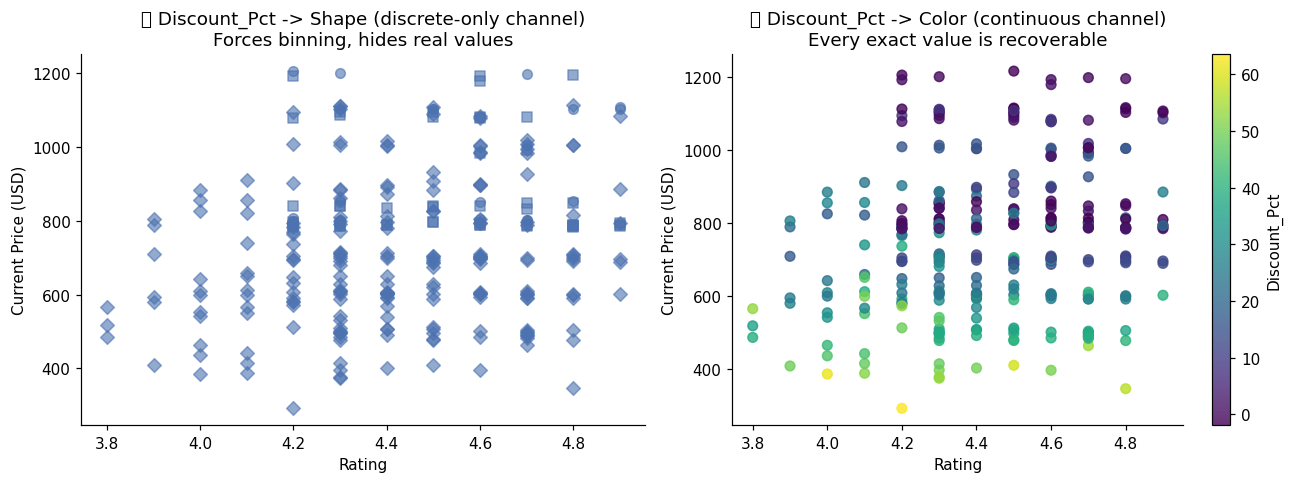

In [4]:
sub = df[df["Product_Category"] == "iPhone"].sample(300, random_state=7)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- WRONG: continuous variable forced into a discrete channel (shape) ---
# We only have a handful of marker shapes, so we must artificially BIN a continuous
# variable to force it into shape -- this is exactly the mapping error from Slide 8/9.
bins = pd.cut(sub["Discount_Pct"], bins=[-1, 0, 3, 6, 100], labels=["o", "s", "^", "D"])
for marker in bins.cat.categories:
    m = bins == marker
    axes[0].scatter(sub.loc[m, "Rating"], sub.loc[m, "Current_Price_USD"],
                     marker=marker, alpha=0.6, color="#4C72B0", s=40)
axes[0].set_title("❌ Discount_Pct -> Shape (discrete-only channel)\nForces binning, hides real values")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Current Price (USD)")

# --- RIGHT: continuous variable mapped to a continuous channel (color) ---
sc = axes[1].scatter(sub["Rating"], sub["Current_Price_USD"], c=sub["Discount_Pct"],
                      cmap="viridis", s=40, alpha=0.8)
axes[1].set_title("✅ Discount_Pct -> Color (continuous channel)\nEvery exact value is recoverable")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Current Price (USD)")
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label("Discount_Pct")

plt.tight_layout()
plt.show()


🔧 **Try it:** In the left panel, count how many distinct discount values got squashed
into the `"o"` (circle) bucket. That's information the reader can *never* recover — this
is precisely the mapping error the MCQs on Slides 17–22 are testing you on.


## 4. Scales: The Mathematical Bridge  *(Slide 10)*

A **scale** is the function that maps a data value to an aesthetic value. For a scale to
be trustworthy it must be **bijective** (one-to-one) — every data value maps to a unique
visual value, and a reader can invert the mapping to recover the number.

Here we stack **three simultaneous scales** on one chart — position (x, y), size, and
color — to show how much a well-designed multi-scale chart can carry at once.


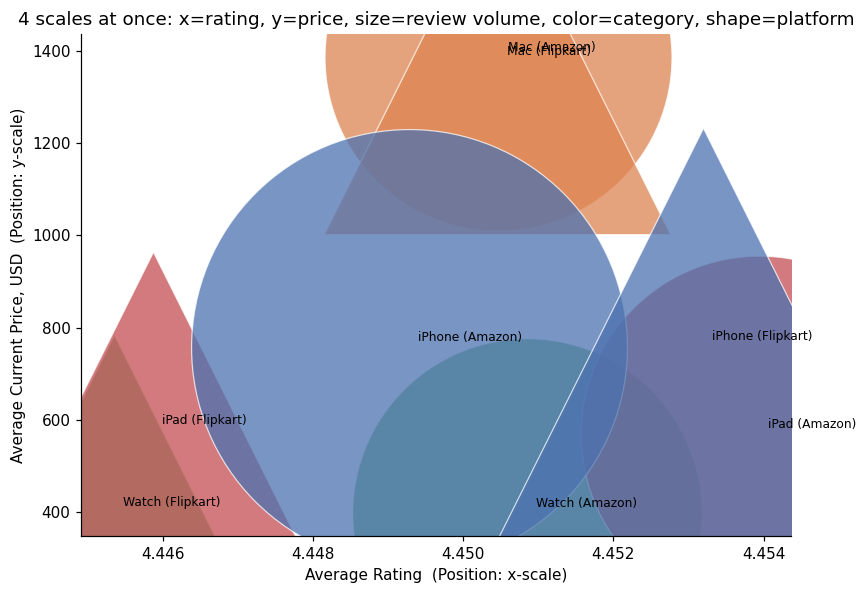

Every mark on this chart is decodable back to 5 numbers/categories -- that's the power of bijective scales.


In [5]:
agg = (df.groupby(["Product_Category", "Platform"])
         .agg(avg_price=("Current_Price_USD", "mean"),
              avg_rating=("Rating", "mean"),
              total_reviews=("Reviews_Count", "sum"))
         .reset_index())

fig, ax = plt.subplots(figsize=(8, 5.5))
platform_marker = {"Amazon": "o", "Flipkart": "^"}
cat_color = {"iPhone": "#4C72B0", "Mac": "#DD8452", "Watch": "#55A868", "iPad": "#C44E52"}

for _, row in agg.iterrows():
    ax.scatter(row["avg_rating"], row["avg_price"],
               s=row["total_reviews"] / 400,
               marker=platform_marker[row["Platform"]],
               color=cat_color[row["Product_Category"]],
               alpha=0.75, edgecolor="white", linewidth=0.8)
    ax.annotate(f"{row['Product_Category']} ({row['Platform']})",
                (row["avg_rating"], row["avg_price"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel("Average Rating  (Position: x-scale)")
ax.set_ylabel("Average Current Price, USD  (Position: y-scale)")
ax.set_title("4 scales at once: x=rating, y=price, size=review volume, color=category, shape=platform")
plt.tight_layout()
plt.show()

print("Every mark on this chart is decodable back to 5 numbers/categories -- that's the power of bijective scales.")


## 5. Lines and Paths as Temporal Guides  *(Slide 11)*

Time-series data benefits from **lines** because they emphasize the chronological path
between points. When the series is dense, dropping the individual point markers keeps
the chart clean without losing the trend.


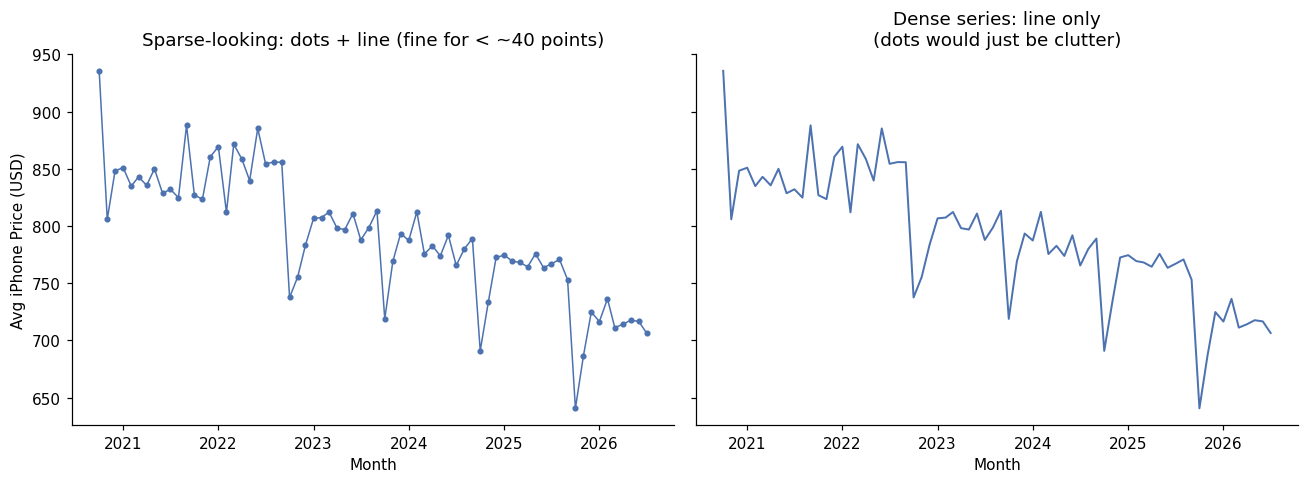

In [6]:
monthly = (df[df["Product_Category"] == "iPhone"]
           .set_index("Date")
           .resample("MS")["Current_Price_USD"]
           .mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

axes[0].plot(monthly.index, monthly.values, marker="o", markersize=3, linewidth=1, color="#4C72B0")
axes[0].set_title("Sparse-looking: dots + line (fine for < ~40 points)")

axes[1].plot(monthly.index, monthly.values, linewidth=1.3, color="#4C72B0")
axes[1].set_title("Dense series: line only\n(dots would just be clutter)")

for ax in axes:
    ax.set_xlabel("Month")
axes[0].set_ylabel("Avg iPhone Price (USD)")
plt.tight_layout()
plt.show()


## 6. Noise Reduction and Area Fills — the Principle of Proportional Ink  *(Slide 12)*

**Rule:** an area-fill chart is only mathematically valid if the vertical scale starts
at **zero**. If you truncate the y-axis, the *shaded area* no longer corresponds
proportionally to the underlying values — the reader's eye is deceived even if the axis
labels are technically correct.

Watch what happens to the *same* data when we simply change the y-axis lower limit.


/tmp/ipykernel_582/2523723009.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_582/2523723009.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


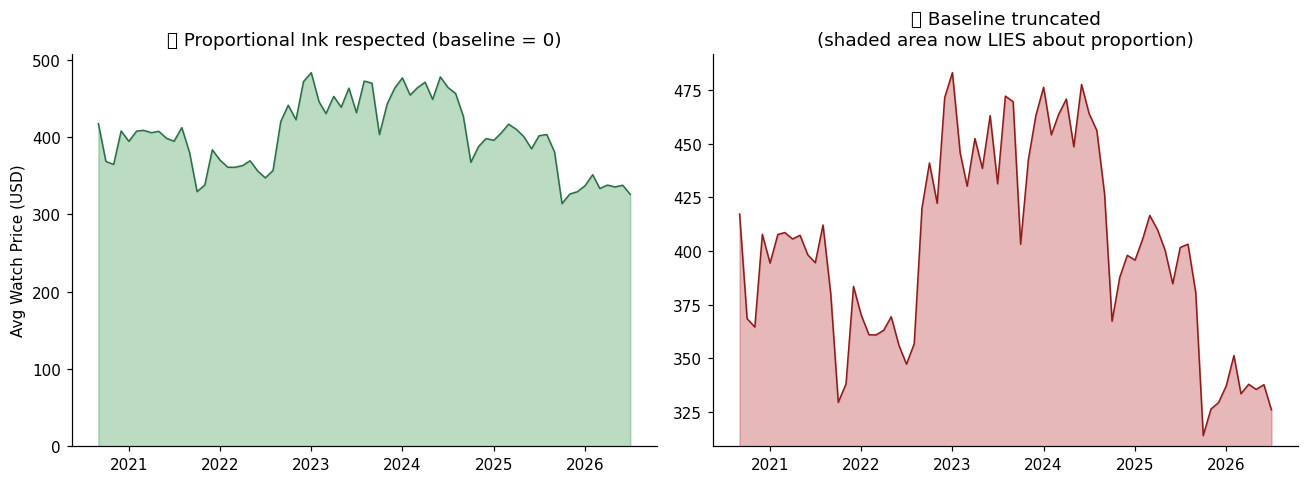

Actual price range: 314 to 483 USD
Right panel's shaded area looks ~3x bigger for a ~5% price swing. That's the distortion the lecture warned about.


In [7]:
monthly_watch = (df[df["Product_Category"] == "Watch"]
                  .set_index("Date")
                  .resample("MS")["Current_Price_USD"]
                  .mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

axes[0].fill_between(monthly_watch.index, monthly_watch.values, 0, color="#55A868", alpha=0.4)
axes[0].plot(monthly_watch.index, monthly_watch.values, color="#2c6e49", linewidth=1)
axes[0].set_ylim(bottom=0)
axes[0].set_title("✅ Proportional Ink respected (baseline = 0)")
axes[0].set_ylabel("Avg Watch Price (USD)")

axes[1].fill_between(monthly_watch.index, monthly_watch.values, monthly_watch.min() - 5, color="#C44E52", alpha=0.4)
axes[1].plot(monthly_watch.index, monthly_watch.values, color="#8c1c1c", linewidth=1)
axes[1].set_ylim(bottom=monthly_watch.min() - 5)
axes[1].set_title("❌ Baseline truncated\n(shaded area now LIES about proportion)")

plt.tight_layout()
plt.show()

print(f"Actual price range: {monthly_watch.min():.0f} to {monthly_watch.max():.0f} USD")
print("Right panel's shaded area looks ~3x bigger for a ~5% price swing. That's the distortion the lecture warned about.")


## 7. Direct Line Labeling vs. Distant Legends  *(Slide 13)*

A legend forces the reader's eye to bounce between the chart and a separate key. **Direct
labels** — placing the category name right at the end of its own line, color-matched —
remove that round trip entirely.


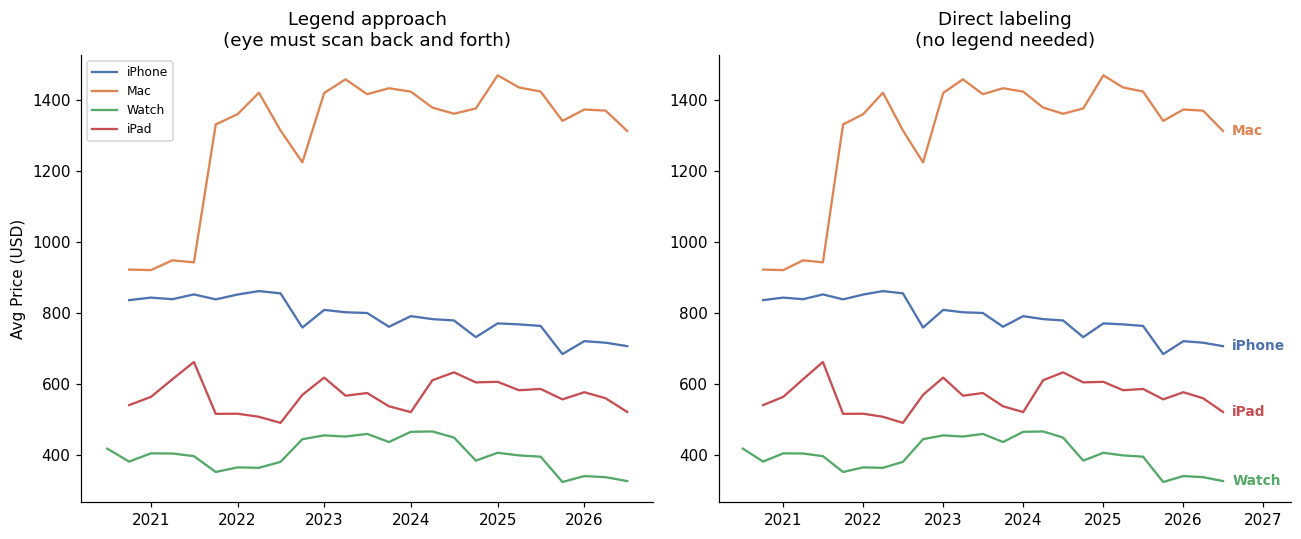

In [8]:
monthly_by_cat = (df.set_index("Date")
                   .groupby("Product_Category")
                   .resample("QS")["Current_Price_USD"]
                   .mean()
                   .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for cat, color in cat_color.items():
    d = monthly_by_cat[monthly_by_cat["Product_Category"] == cat]
    axes[0].plot(d["Date"], d["Current_Price_USD"], color=color, linewidth=1.5, label=cat)
axes[0].legend(loc="upper left", fontsize=8)
axes[0].set_title("Legend approach\n(eye must scan back and forth)")
axes[0].set_ylabel("Avg Price (USD)")

for cat, color in cat_color.items():
    d = monthly_by_cat[monthly_by_cat["Product_Category"] == cat]
    axes[1].plot(d["Date"], d["Current_Price_USD"], color=color, linewidth=1.5)
    last = d.iloc[-1]
    axes[1].annotate(cat, (last["Date"], last["Current_Price_USD"]),
                      textcoords="offset points", xytext=(6, 0),
                      color=color, fontsize=9, fontweight="bold", va="center")
axes[1].set_xlim(axes[1].get_xlim()[0], axes[1].get_xlim()[1] + 200)
axes[1].set_title("Direct labeling\n(no legend needed)")

plt.tight_layout()
plt.show()


## 8. Bar Plot — the Zero-Baseline Rule  *(Slide 14)*

For a bar's **length** to honestly represent its value, bars must start at zero. Bar
*area* (or length) is the channel; if the baseline isn't zero, area-to-value proportion
breaks — the exact same Principle of Proportional Ink from Section 6, now applied to bars.


/tmp/ipykernel_582/3323888889.py:15: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_582/3323888889.py:15: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


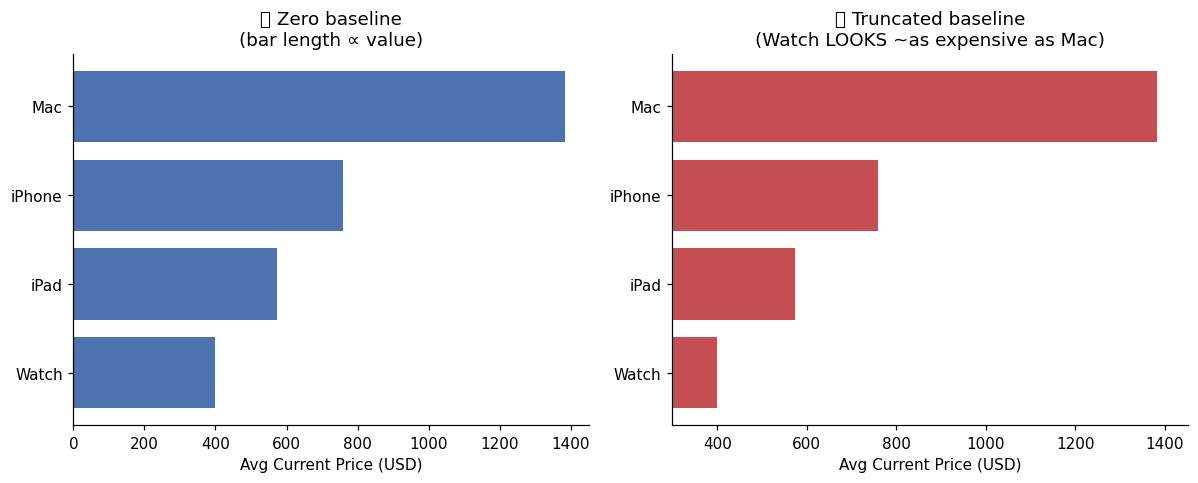

Product_Category
Watch      398.6
iPad       573.1
iPhone     758.7
Mac       1382.5
Name: Current_Price_USD, dtype: float64


In [9]:
cat_avg = df.groupby("Product_Category")["Current_Price_USD"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].barh(cat_avg.index, cat_avg.values, color="#4C72B0")
axes[0].set_xlim(left=0)
axes[0].set_title("✅ Zero baseline\n(bar length ∝ value)")
axes[0].set_xlabel("Avg Current Price (USD)")

axes[1].barh(cat_avg.index, cat_avg.values, color="#C44E52")
axes[1].set_xlim(left=cat_avg.min() - 100)
axes[1].set_title("❌ Truncated baseline\n(Watch LOOKS ~as expensive as Mac)")
axes[1].set_xlabel("Avg Current Price (USD)")

plt.tight_layout()
plt.show()

print(cat_avg.round(1))


## 9. Grouped vs. Stacked Bar Charts vs. Small Multiples  *(Slide 15)*

- **Grouped bars**: side-by-side, easy to compare *within* a category across platforms.
- **Stacked bars**: show the combined total, but baseline-shifting makes internal
  segments hard to compare to each other.
- **Small multiples**: separate mini-charts per category — no color clutter, easy
  comparison of magnitudes.


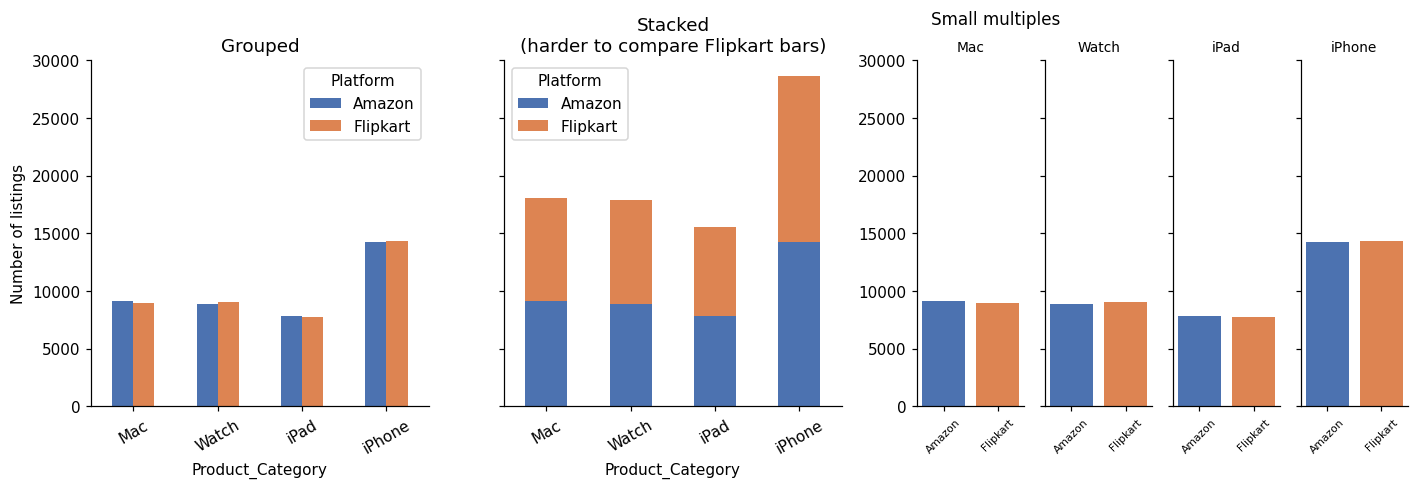

In [10]:
counts = (df.groupby(["Product_Category", "Platform"])
          .size()
          .unstack())

fig = plt.figure(figsize=(13, 4.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.1, 1.6])

# Grouped
ax0 = fig.add_subplot(gs[0])
counts.plot(kind="bar", ax=ax0, color=["#4C72B0", "#DD8452"])
ax0.set_title("Grouped")
ax0.set_ylabel("Number of listings")
ax0.tick_params(axis='x', rotation=30)

# Stacked
ax1 = fig.add_subplot(gs[1], sharey=ax0)
counts.plot(kind="bar", stacked=True, ax=ax1, color=["#4C72B0", "#DD8452"])
ax1.set_title("Stacked\n(harder to compare Flipkart bars)")
ax1.tick_params(axis='x', rotation=30)

# Small multiples
gs_inner = gs[2].subgridspec(1, len(counts.index))
for i, cat in enumerate(counts.index):
    axm = fig.add_subplot(gs_inner[i], sharey=ax0)
    axm.bar(counts.columns, counts.loc[cat], color=["#4C72B0", "#DD8452"])
    axm.set_title(cat, fontsize=9)
    axm.tick_params(axis='x', rotation=45, labelsize=7)
    if i > 0:
        axm.tick_params(labelleft=False)
fig.text(0.7, 0.95, "Small multiples", ha="center", fontsize=11)

plt.tight_layout()
plt.show()


## 10. Points as Marks: Scatter Plots and Bubble Charts  *(Slide 16)*

Scatter plots reveal the relationship between two continuous variables. Adding a
**bubble size** channel lets a third continuous variable ride along on the same marks.


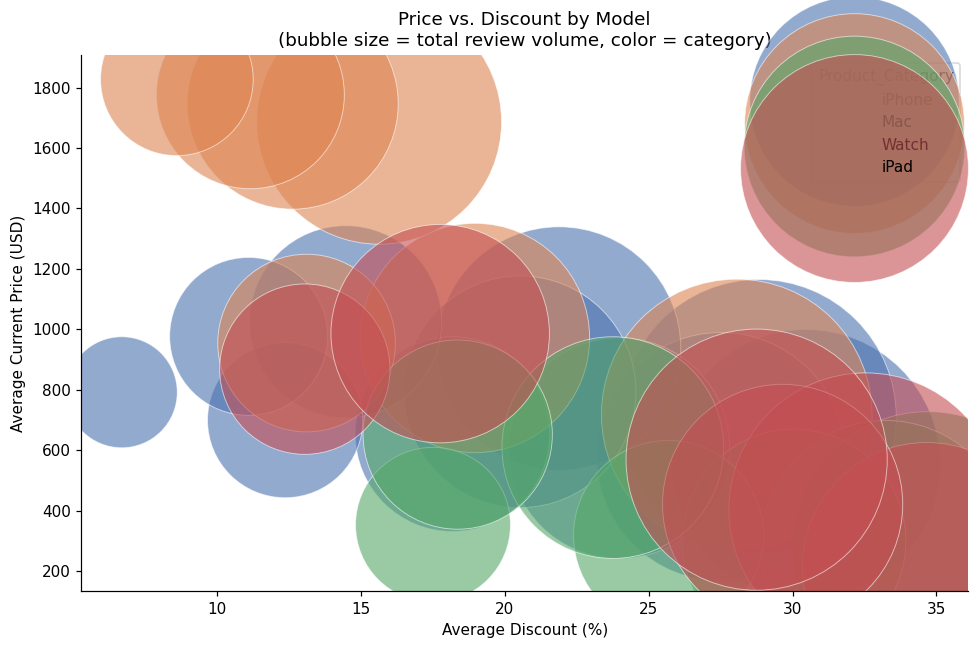

In [11]:
model_summary = (df.groupby(["Model_Name", "Product_Category"])
                  .agg(avg_price=("Current_Price_USD", "mean"),
                       avg_discount=("Discount_Pct", "mean"),
                       total_reviews=("Reviews_Count", "sum"))
                  .reset_index())

fig, ax = plt.subplots(figsize=(9, 6))
for cat, color in cat_color.items():
    d = model_summary[model_summary["Product_Category"] == cat]
    ax.scatter(d["avg_discount"], d["avg_price"], s=d["total_reviews"] / 300,
               color=color, alpha=0.6, edgecolor="white", linewidth=0.6, label=cat)

ax.set_xlabel("Average Discount (%)")
ax.set_ylabel("Average Current Price (USD)")
ax.set_title("Price vs. Discount by Model\n(bubble size = total review volume, color = category)")
ax.legend(title="Product_Category")
plt.tight_layout()
plt.show()


## 11. Practical Takeaways

| Concept | What you just saw |
|---|---|
| Marks vs. Channels | Same points, more channels (color, size) = more data per mark |
| Continuous vs. discrete aesthetics | Binning `Discount_Pct` into shapes destroys information; color preserves it |
| Bijective scales | 4-scale bubble chart, still fully decodable |
| Proportional Ink | Truncated baselines visually lie about magnitude — in *both* area fills and bars |
| Direct labeling | Removes the legend round-trip |
| Grouped / stacked / small multiples | Different trade-offs for the same underlying counts |
| Scatter / bubble | A third continuous variable riding on marker size |

